In [1]:
company_to_ticker = {
    "apple": "AAPL",
    "samsung": "005930.KS",
    "tcs": "TCS.NS",
    "microsoft": "MSFT",
    "google": "GOOGL",
    "amazon": "AMZN",
    "infosys": "INFY.NS",
    "wipro": "WIPRO.NS"
    # 🔁 Add more as needed
}


In [2]:
company_name = input("Enter company name (e.g., Apple, Samsung, TCS): ").lower()


if company_name in company_to_ticker:
    ticker = company_to_ticker[company_name]
    print(f"✅ Found ticker: {ticker}")
else:
    raise ValueError("❌ Company name not recognized. Please try a valid one.")


✅ Found ticker: TCS.NS


In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [4]:

start_date = '2015-01-01'
end_date = '2024-01-01'

In [5]:
data = yf.download(ticker, start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [6]:
os.makedirs("../data", exist_ok=True)
data.to_csv("../data/stock_data.csv")
print("✅ Data downloaded and saved as '../data/stock_data.csv'")


✅ Data downloaded and saved as '../data/stock_data.csv'


In [7]:


# Define the function to download and save data
def download_and_save_data(ticker):
    try:
        # Fetch stock data for the given ticker symbol
        stock_data = yf.download(ticker, period="5y", interval="1d")
        
        # Check if data is empty
        if stock_data.empty:
            print(f"No data found for ticker: {ticker}")
            return
        
        # Create a directory for saving data if it doesn't exist
        os.makedirs("../data", exist_ok=True)
        
        # Use the ticker symbol as the filename (or you can extract the company name)
        filename = f"../data/{ticker}_stock_data.csv"
        
        # Save the data to the CSV file
        stock_data.to_csv(filename)
        
        print(f"✅ Data downloaded and saved as '{filename}'")
    
    except Exception as e:
        print(f"❌ Failed to download data for ticker: {ticker}. Error: {str(e)}")

# Example of entering the company ticker symbol  # Convert to uppercase for consistency
download_and_save_data(ticker)


[*********************100%***********************]  1 of 1 completed

✅ Data downloaded and saved as '../data/TCS.NS_stock_data.csv'


In [8]:
data = pd.read_csv("../data/stock_data.csv", parse_dates=True)
print(data.head())
print(data.describe())
print(data.columns)

        Price               Close                High                 Low  \
0      Ticker              TCS.NS              TCS.NS              TCS.NS   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-01      1049.376953125  1058.2194759486172  1047.5012420667847   
3  2015-01-02  1063.3521728515625   1068.092931625439  1051.4591123142368   
4  2015-01-05   1047.192138671875  1071.7822021722864  1040.7611576156253   

                 Open   Volume  
0              TCS.NS   TCS.NS  
1                 NaN      NaN  
2  1058.2194759486172   366830  
3   1051.623968013787   925740  
4   1063.990910308871  1754242  
             Price               Close                High                Low  \
count         2223                2222                2222               2222   
unique        2223                2211                2222               2222   
top     2023-12-29  1781.3289794921875  3759.3402550951864  3703.086660331394   
freq           

In [9]:
# Ensure the 'Close' column is numeric
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

# Calculate moving averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()


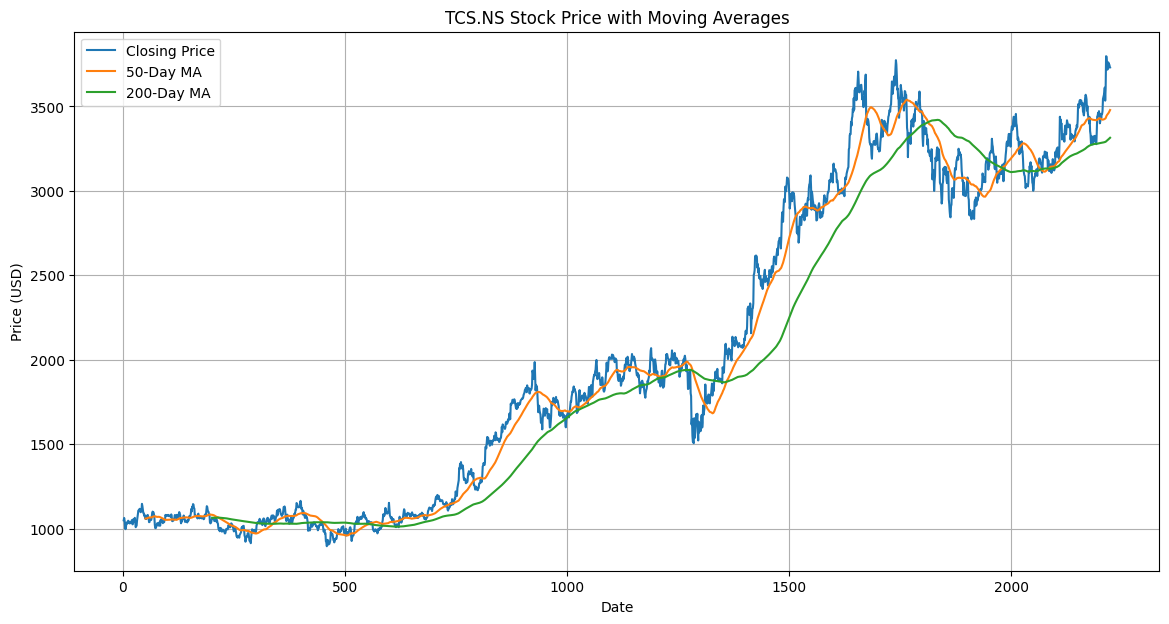

In [10]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Closing Price')
plt.plot(data['MA50'], label='50-Day MA')
plt.plot(data['MA200'], label='200-Day MA')
plt.title(f'{ticker} Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

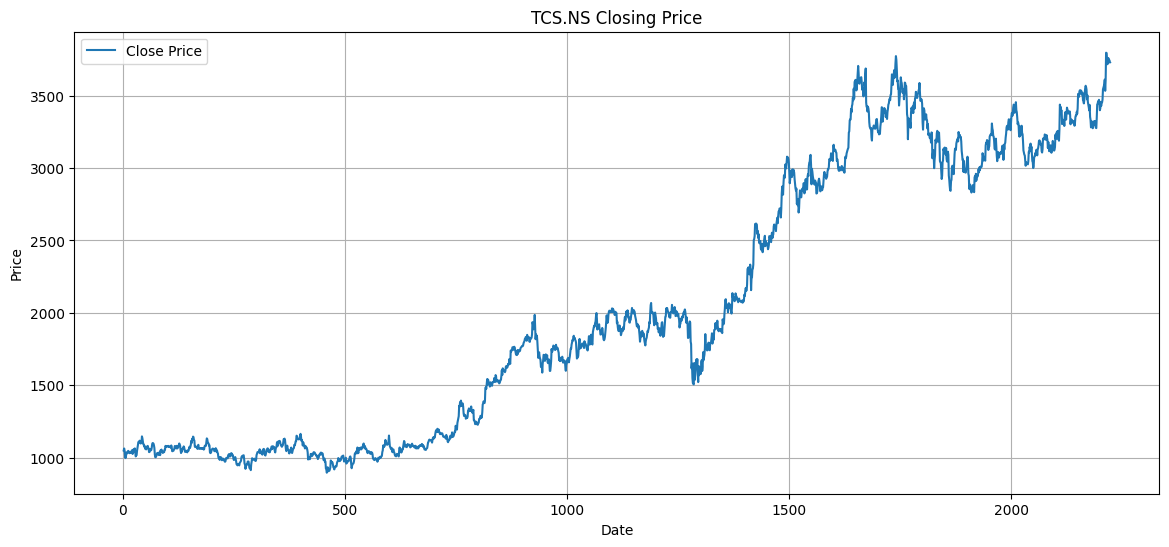

In [11]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Close Price')
plt.title(f'{ticker} Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

<Figure size 1400x600 with 0 Axes>

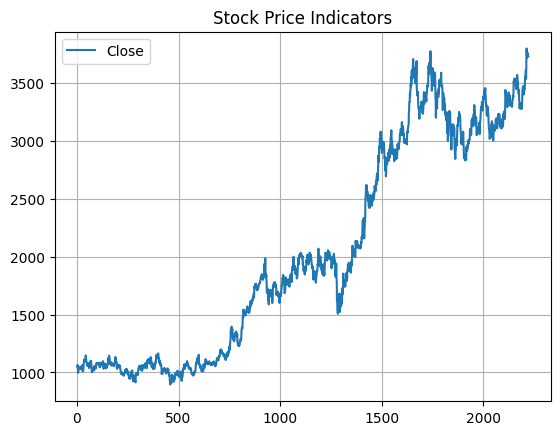

In [12]:
plt.figure(figsize=(14, 6))
data[['Open', 'High', 'Low', 'Close']].plot(title="Stock Price Indicators")
plt.grid()
plt.show()

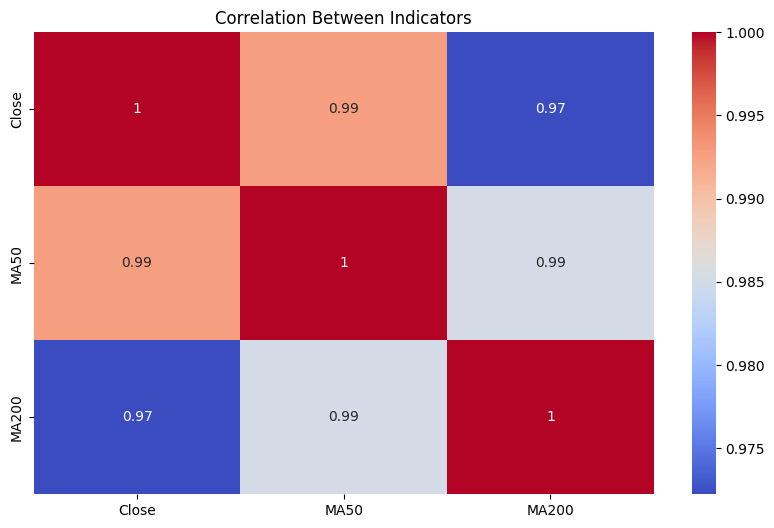

In [13]:
# Select only numeric columns for correlation
numeric_data = data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Indicators")
plt.show()

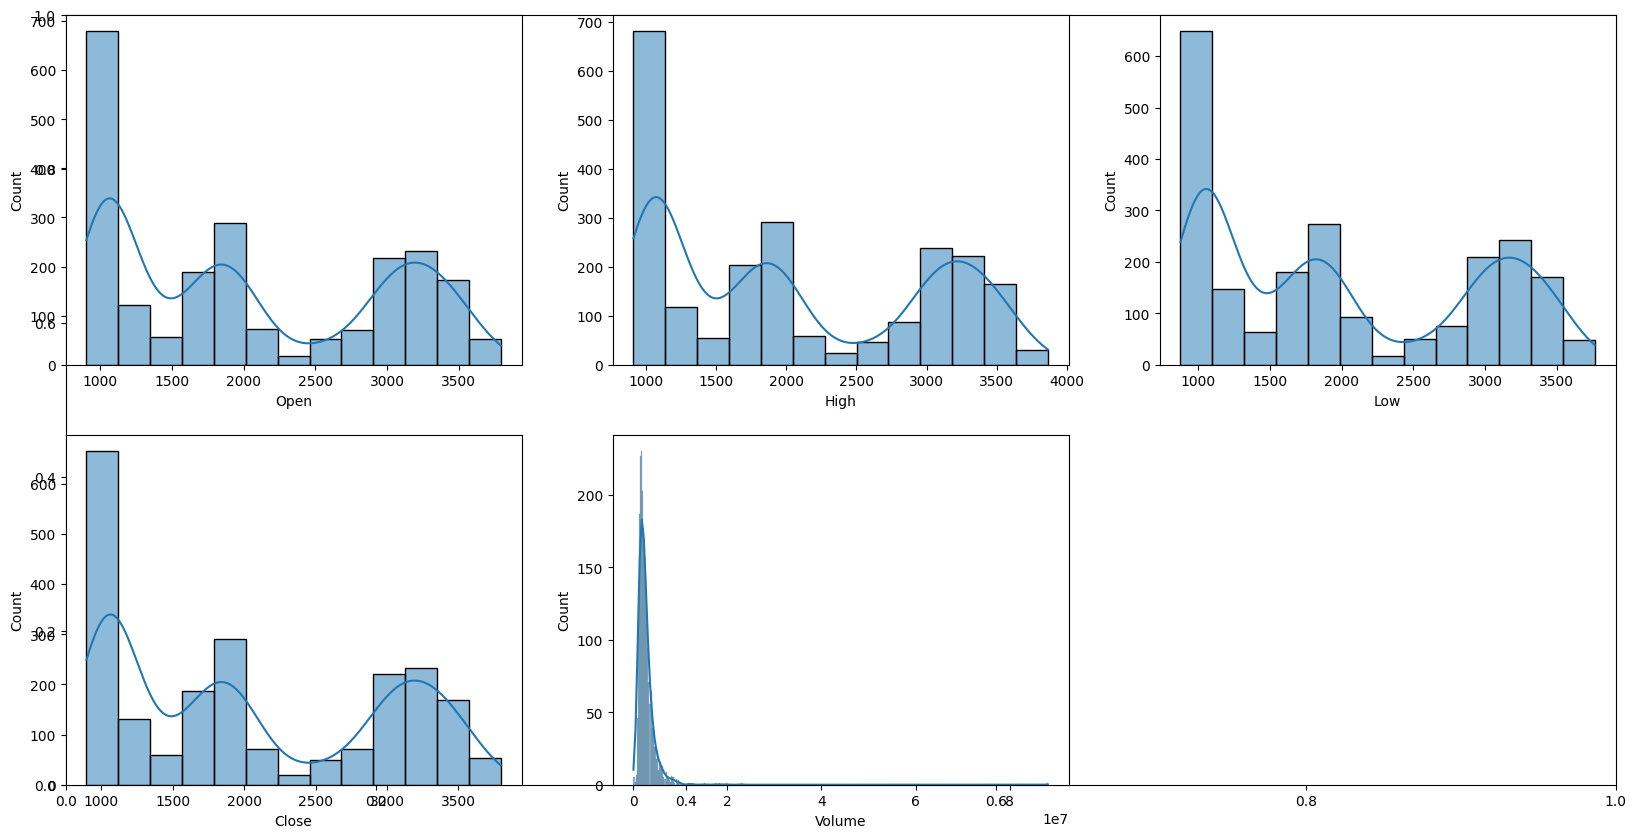

In [14]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Convert columns to numeric, coercing errors to NaN
for col in features:
    data[col] = pd.to_numeric(data[col], errors='coerce')

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data[col], kde=True)  # Updated to use sns.histplot instead of sns.distplot (deprecated)
plt.show()